# Relatório Técnico

# LIACD – Trabalho #1: From Raw Detections to Real Intelligence 

# Trabalho realizado por: Bruno Vicente (number 55300)

## Introdução 

   Uma loja moderna com 23 áreas distintas (mapeadas topologicamente no ficheiro zones.json) está equipada com um sistema de visão computacional que capta continuamente a atividade dos clientes. O sistema gera deteções (events.csv) contendo o event_id (identificador único do evento), timestamp (data e hora), zone_id (a zona onde ocorreu) e o tipo de evento (entry, exit ou linger, com a respetiva duração). Adicionalmente, capta atributos demográficos estimados, como o género (gender) e a faixa etária (age_range), que estão sujeitos a erros de classificação na ordem dos 8% e 12%, respetivamente.  A dificuldade central deste dataset reside na total ausência de um identificador pessoal (person_id). Com estes sistemas, sabemos que uma determinada pessoa esteve na zona X a uma dada hora, mas não sabemos, à partida, se é a mesma pessoa que foi detetada no minuto seguinte noutra área da loja. Temos múltiplas pessoas presentes em simultâneo, intercalando os seus eventos num mar de ruído. O problema a resolver tem a ver com a reconstrução de trajetórias individuais através de heurísticas de associação espaço temporal.  

Para resolver este desafio, adotei uma decisão arquitetural estrita, dividindo o sistema em duas fases. A primeira fase é puramente algorítmica e matemática (Stitching e Analytics), sendo responsável por domar a escala e a complexidade dos dados. A segunda fase introduz a Inteligência Artificial (LLM). Em vez de alimentar o modelo de linguagem com milhares de linhas CSV em bruto, apliquei o Princípio de Separação uma vez que o LLM nunca acede aos dados originais nem executa cálculos. Ele recebe exclusivamente um resumo estatístico estruturado (metrics.json) pré-processado. Esta separação garante a síntese semântica e a extração de insights operacionais da LLM.

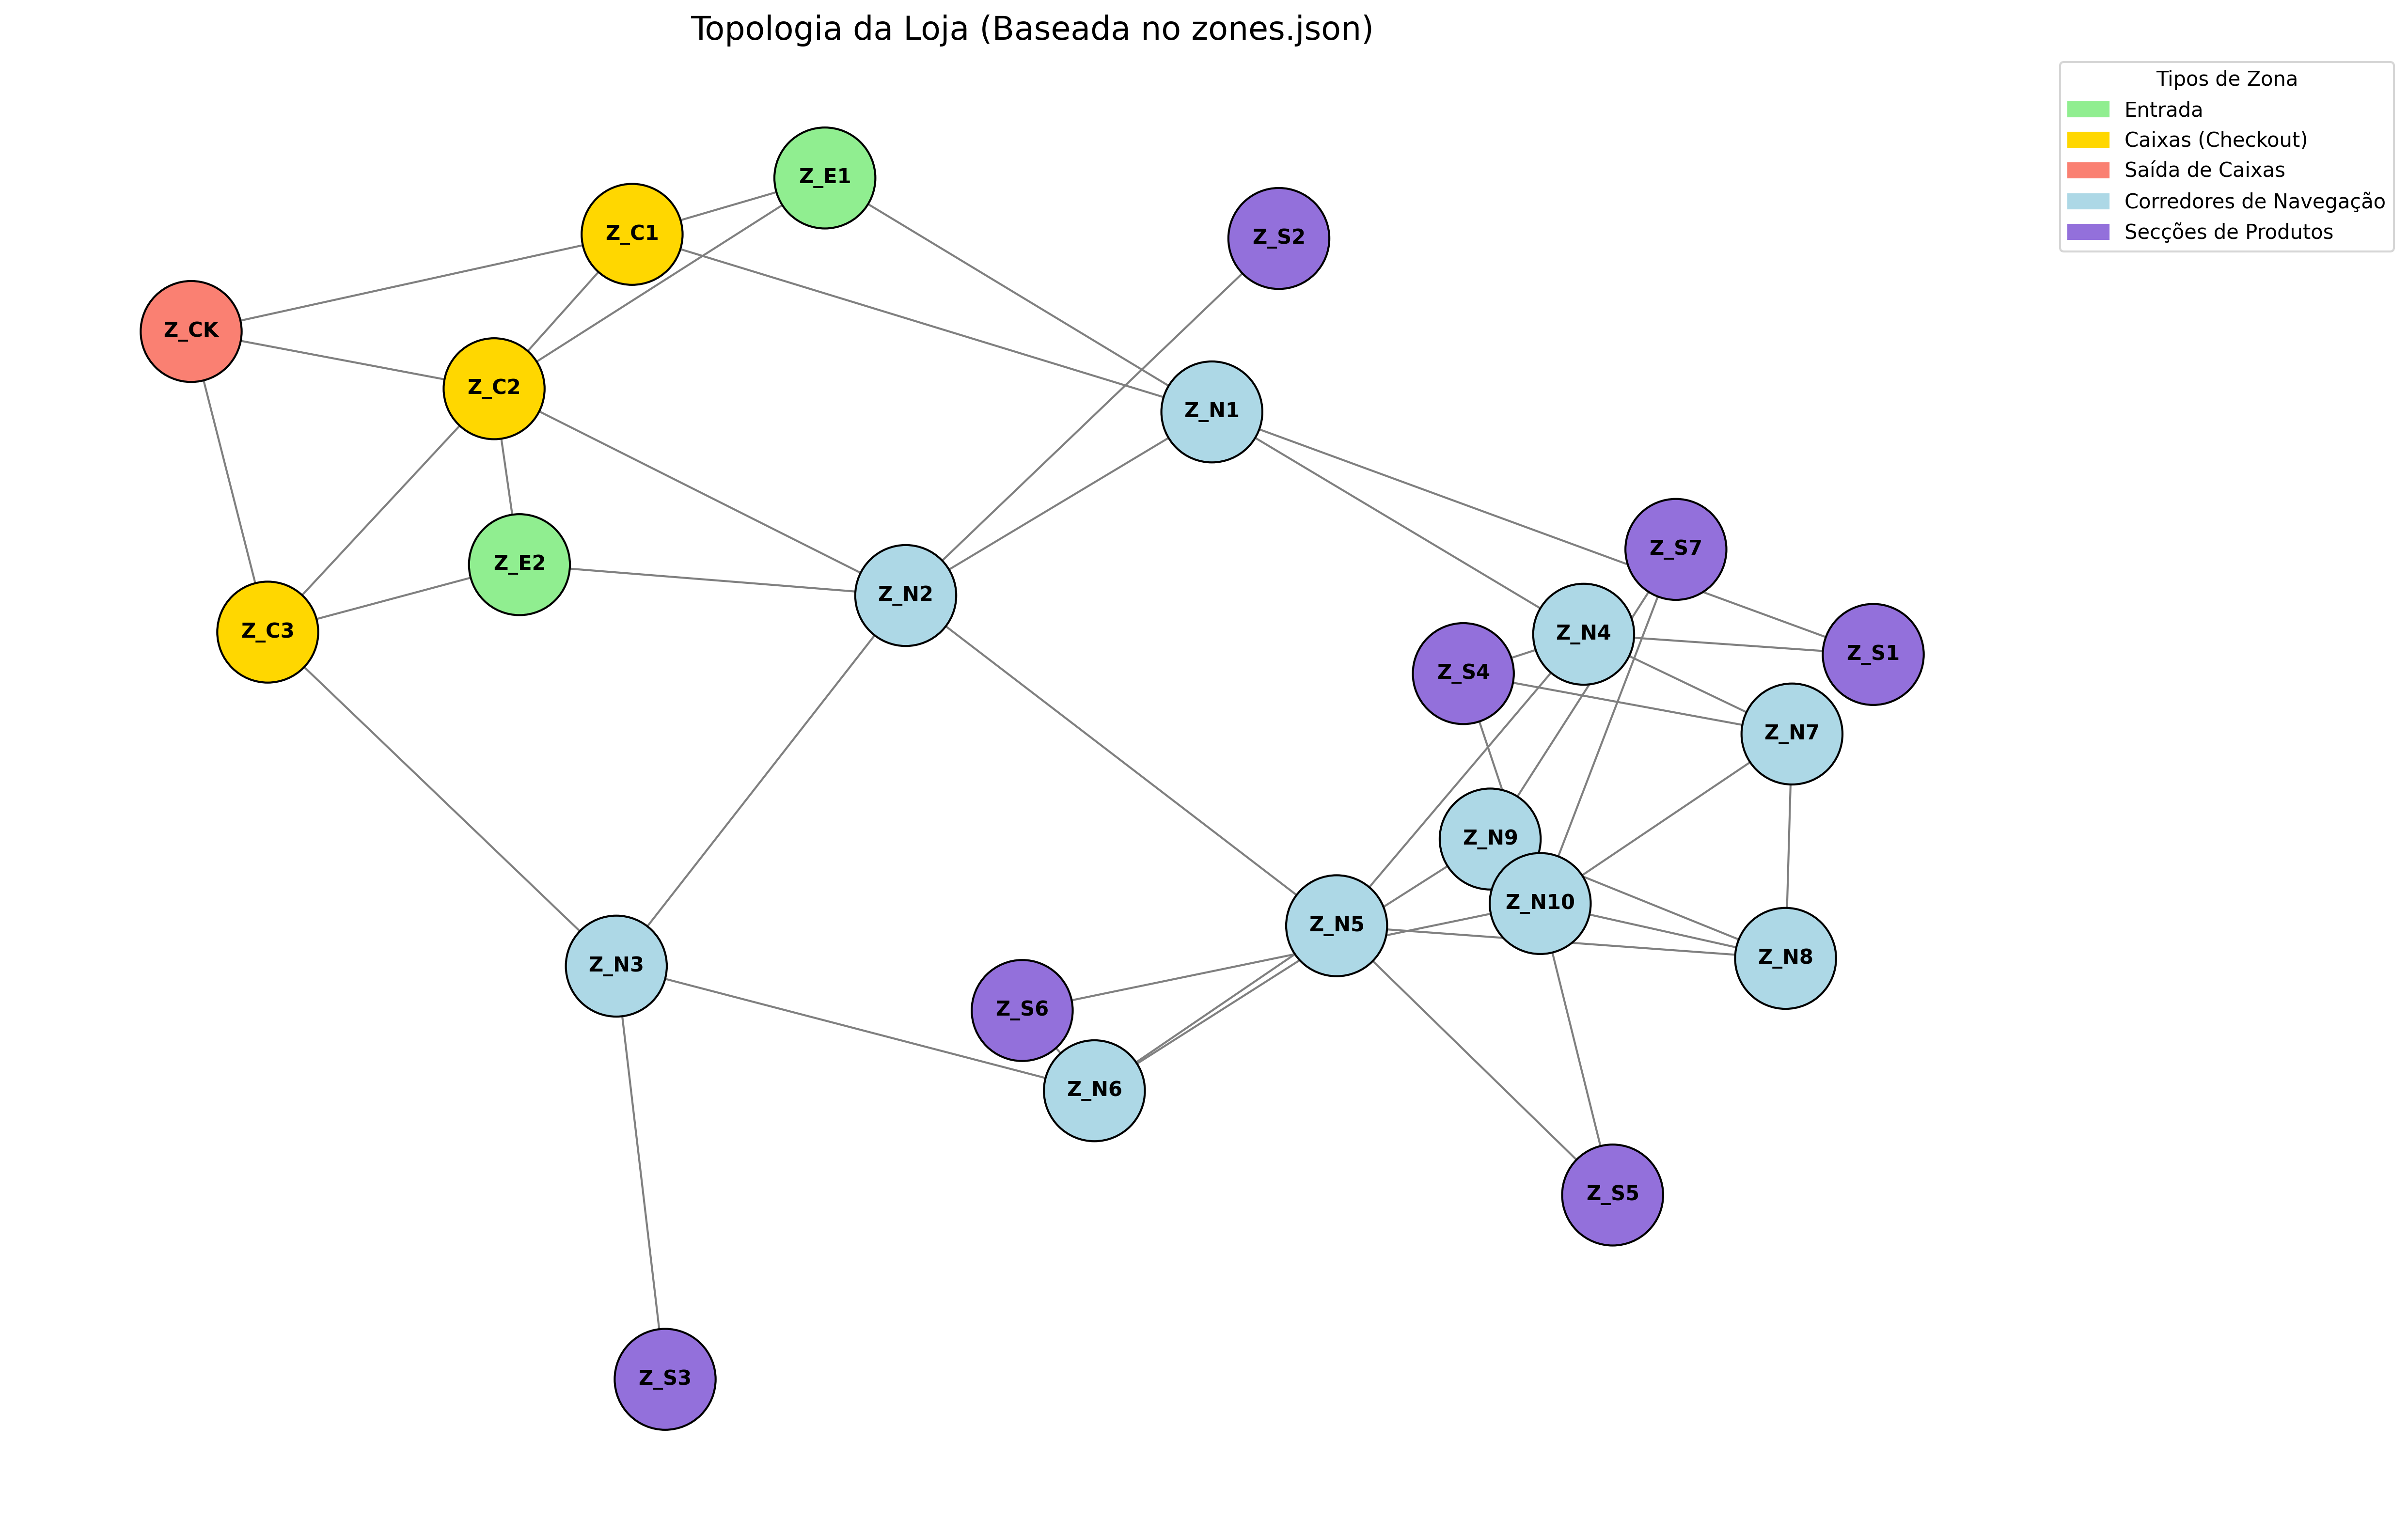

Estrutura do events.csv

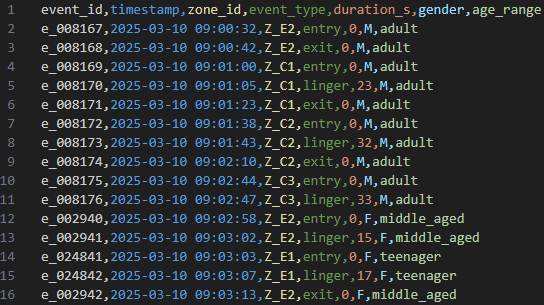

## Algoritmo de stitching

Tendo como problema principal processar um stream de centenas de milhares de eventos (raw detections) e reconstruir jornadas individuais com significado. O maior inimigo desta fase foi a latência onde a minha jornada começou com a luta contra o crescimento exponencial do custo computacional

Após uma análise rigorosa ao enunciado e com todos os pontos importantes bem anotados, foquei-me no planeamento da arquitetura antes sequer de começar a implementação. Desde o início, tive em mente que uma abordagem ingénua para o stitching de trajetórias seria comparar cada novo evento com todas as trajetórias já abertas no sistema, tal como nos é alertado no ponto 7 do enunciado. Numa escala de centenas de milhares de linhas, este algoritmo resultaria numa complexidade quadrática ($O(N^2)$), tornando o processamento impraticável, pois muito dificilmente algum hardware de consumo seria capaz de correr o código sem ser levado à exaustão.Para resolver este problema, decidi implementar uma arquitetura baseada em Dicionários (Hash Maps). Em vez de uma pesquisa cega, o nosso motor utiliza tuplos demográficos (zone_id, gender, age_range) como chaves de acesso imediato. Isto permite que o sistema encontre candidatos compatíveis em tempo constante $O(1)$, independentemente do tamanho do dataset. Para a gestão de estado, utilizei a estrutura collections.deque. A grande vantagem desta escolha foi que, ao contrário das listas convencionais, o deque permite operações de inserção e remoção nas extremidades com custo computacional mínimo. Desta forma, garanti que a memória do sistema permanece fluida mesmo durante picos de tráfego intenso na loja.

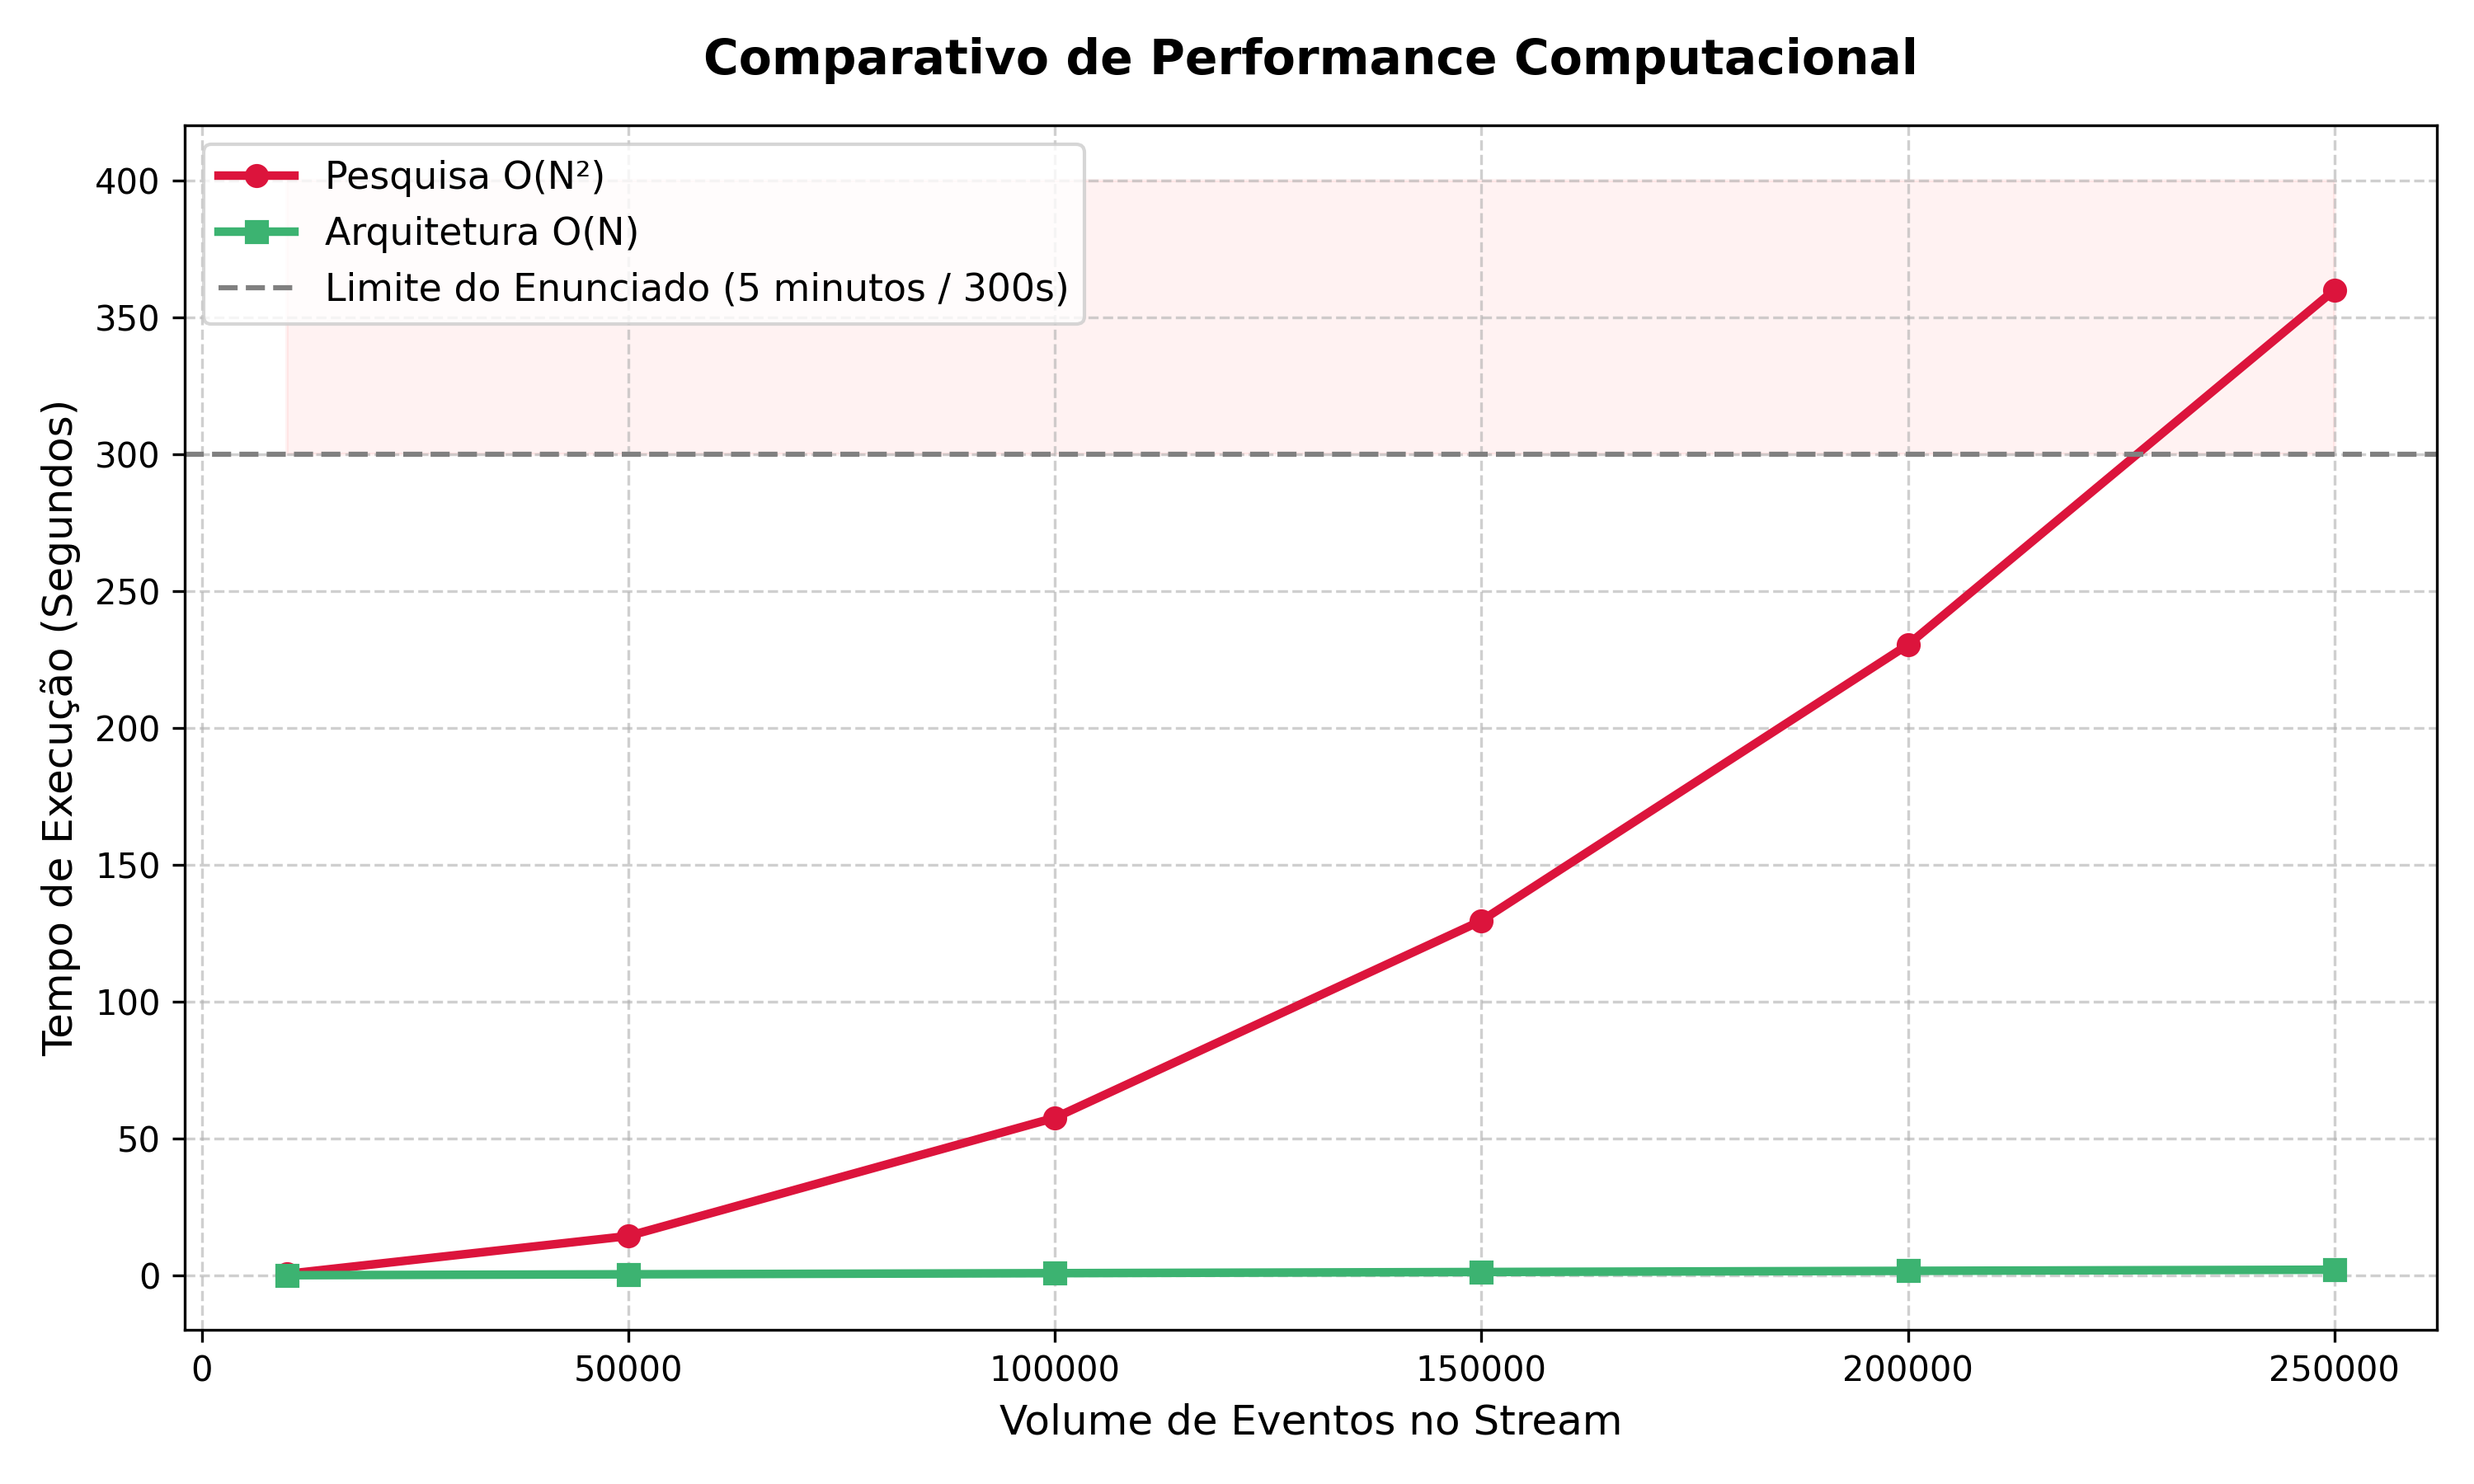

Algo que tive bastante em conta foi o custo oculto do processamento de strings. Uma vez que converter texto em objetos de data/hora (datetime) é uma operação dispendiosa para o CPU, tomei a decisão de manter o campo last_timestamp persistentemente como um objeto nativo. O objetivo foi evitar o parsing contínuo de strings em cada iteração do loop principal, o que me permitiu reduzir drasticamente os ciclos de CPU desperdiçados. Este processo em particular levou a diversas implementações e testes diferentes até o gargalo de performance ser de facto ultrapassado. No final, tornou-se num dos pilares que permitiu ao nosso motor processar o dataset completo em apenas alguns segundos, superando largamente o requisito de 5 minutos imposto pelo enunciado.

No mundo ideal, um sistema de visão computacional regista cada passo de um cliente de forma pura, mas na realidade, as câmaras sofrem oclusões, falhas momentâneas, e os relógios internos dos sensores sofrem com dessincronização de tempo. Para lidar com esta incerteza, tive de abandonar uma abordagem rígida e desenhar um motor resiliente, dividido em três camadas lógicas.

O conceito essencial desta arquitetura foi o Grafo Reverso. A ideia centrou-se em inverter a lógica tradicional, ou seja, em vez de projetar as rotas futuras de um cliente, a premissa passou a ser olhar para o momento atual (ex: saber que esta pessoa em específico apareceu na zona B agora) e, a partir daí, tentar perceber de que zona adjacente poderá ter vindo.

Nível 1: O Fast Path e o Clock Drift
O sistema vai à nossa fila in_transit procurar por um cliente que corresponda exatamente à demografia detetada e cuja origem seja uma zona topologicamente adjacente. Implementei uma margem de tolerância temporal de 10 segundos para acomodar a latência natural de transmissão dos sensores (o Clock Drift). Ou seja, se um cliente demorar um pouco menos a transitar do que o tempo de caminhada estipulado pelo JSON, o Fast Path assume o emparelhamento com sucesso. Desta forma, garantimos uma alta velocidade de processamento nos casos ideais.

Nível 2: O Medium Path e a Distância de Hamming
A grande dificuldade dos dados físicos capturados por estes sensores foi a taxa de erro de classificação demográfica (aproximadamente 8% para o género e 12% para a faixa etária, conforme dito no enunciado). Na prática, isto significa que uma câmara pode detetar um indivíduo corretamente de acordo com o seu género, mas pode errar a sua faixa etária.

Caso o Fast Path falhe, o algoritmo desce para o Medium Path, onde apliquei o conceito matemático da Distância de Hamming. O motor realiza um Fuzzy Match permitindo um nível de tolerância de erro igual a 1 (por exemplo: acerta no género, falha na idade). Em vez de fragmentar a trajetória e assumir falsamente que entrou um novo cliente na loja, o sistema funde a jornada e emite um alerta de "erro do sensor", preservando assim a integridade do percurso da pessoa real.

Nível 3: O Slow Path e os "Teletransportes"
Durante os testes, apercebi-me de que alguns clientes desaparecem numa ponta da loja e reaparecem numa zona não adjacente, sem terem passado pelos corredores. Foi aqui que o Slow Path atuou como último recurso para tentar resolver estas falhas.

Ignorando temporariamente a topologia, este nível varre as filas de trânsito procurando por clientes desaparecidos. Ao encontrá-los, o motor regista a fusão, mas anexa à trajetória um alerta de violação topológica (indicando que uma câmara intermédia falhou completamente). Em suma, esta abordagem tripartida garantiu que o motor analítico não fosse nem demasiado ingénuo face aos dados, nem demasiado estrito ao ponto de perder trajetórias válidas.

Um dos maiores choques de realidade ao trabalhar com streams de sensores é considerar que os dados podem estar errados. O nosso motor de stitching poderia ser algoritmicamente perfeito ($O(1)$), mas se fosse alimentado cegamente com ruído, o resultado final seria apenas mais ruído, e ficou evidente que a limpeza teria de ser tão robusta quanto a própria reconstrução.

##### O "Efeito Ping-Pong" e a Cura do Debouncing

Com recurso à análise topológica que efetuei, ficou evidente que os corredores de navegação atuam como autênticos hubs de tráfego, partilhando fronteiras densas com múltiplas secções de produtos. Esta proximidade gera um fenómeno de Ping-Pong, onde um cliente parado numa fronteira entre duas zonas faz com que as câmaras adjacentes alternem a sua deteção repetidamente em frações de segundo. Por esse motivo, o sistema regista dezenas de micro-eventos falsos de entrada e saída.

Para resolver esta anomalia estrutural, implementei uma rotina de Debouncing temporal. O algoritmo varre o histórico da trajetória e, se detetar o padrão Zona A -> Zona B -> Zona A, onde a passagem pela Zona B durou menos de 5 segundos, o motor funde os três blocos num único evento contínuo na Zona A. Esta ideia foi absolutamente crucial para tratar esta questão de densidade das fronteiras, reduzindo drasticamente a fragmentação falsa das jornadas.

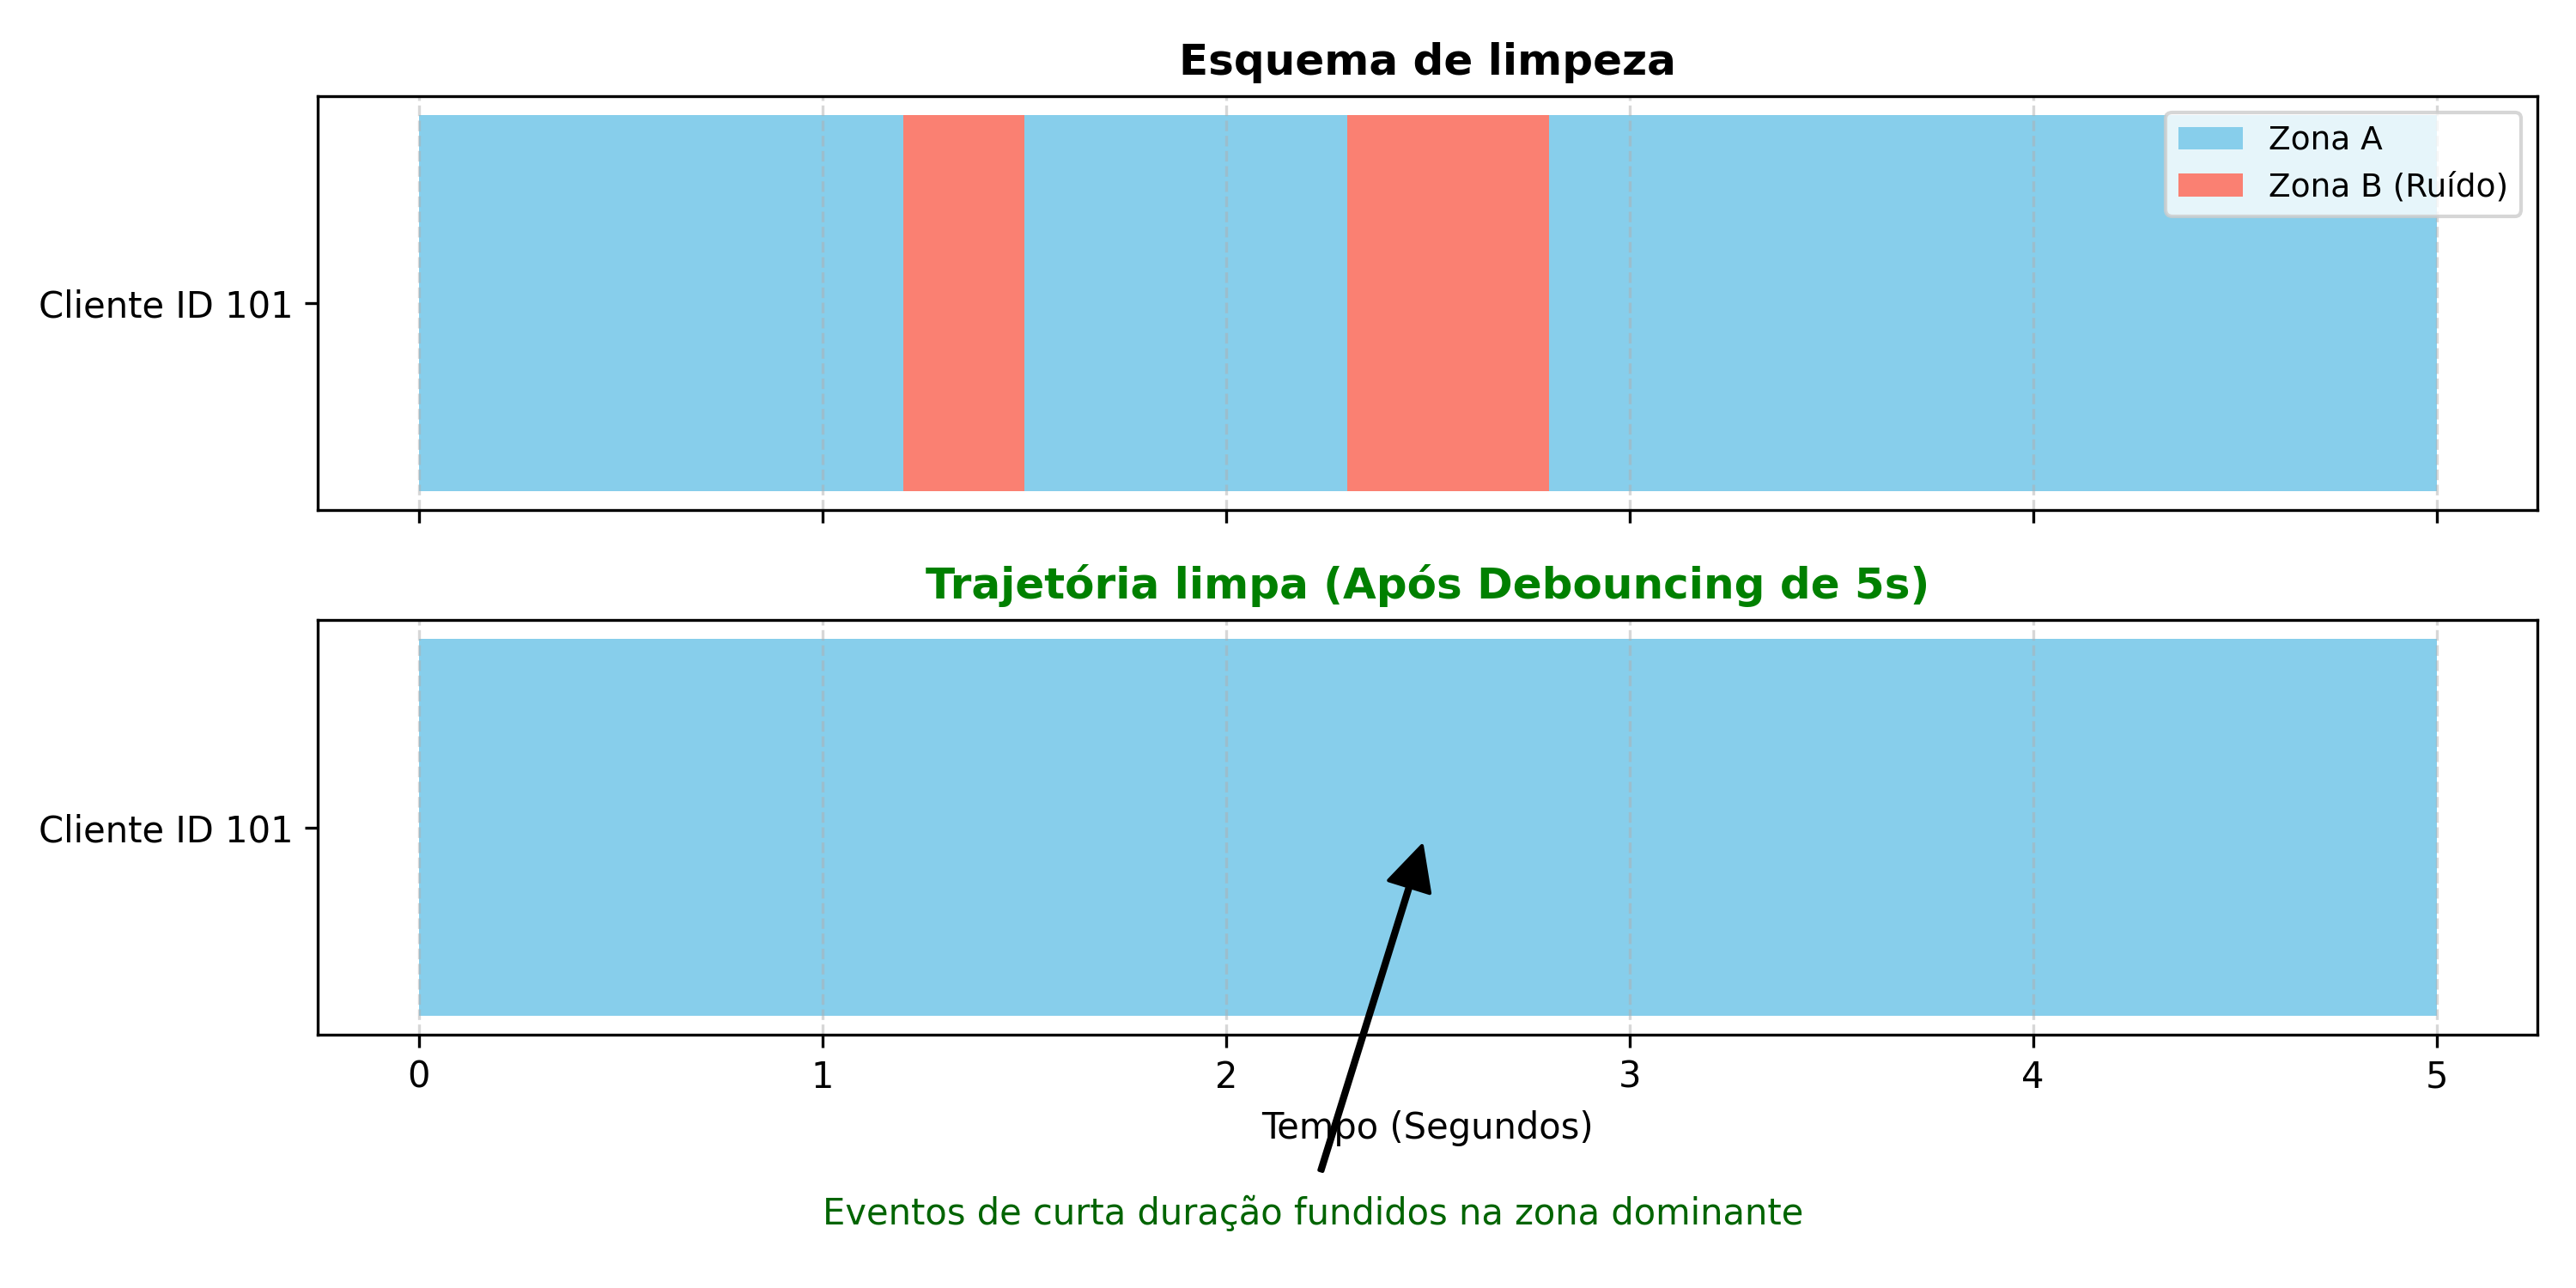

##### Micro-limpeza e a Erradicação de Ghost Tracks

Embora o enunciado mencione apenas erros de classificação genéricos, a minha análise exploratória aos dados revelou outro problema comum que, por norma, estes sistemas de visão computacional apresentam que são os falsos positivos provocados por reflexos rápidos ou sombras. Estes eventos geram trajetórias fantasma (Ghost Tracks) com uma duração de milissegundos, o que estragaria por completo a precisão das nossas estatísticas de conversão no Módulo 2.

Para garantir dados puros, construí um filtro de micro-limpeza no pós-processamento. Qualquer trajetória que não obedeça às regras lógicas de saída da loja (passagem por portas ou caixas) e cuja interação com as zonas dure menos de 3 segundos no total, é automaticamente descartada. A lógica é implacável, pois se não se considerar um comportamento humano válido, o sistema apaga o rasto.

##### O Problema dos Zombies e o Active Sweep Noturno

Por fim, enfrentei o problema da retenção de estado no final do dia de operações. Uma das perguntas que me fiz constantemente foi: "O que acontece aos clientes que ainda estão na fila in_zone ou na fila in_transit quando o ficheiro de eventos do dia chega ao fim?"

Encontrar uma abordagem para tratar desta questão não foi fácil. No início do desenvolvimento, estes clientes retidos ficavam esquecidos na memória do sistema, perdendo-se assim dados valiosos. A solução definitiva foi criar um mecanismo de Active Sweep. Quando a última linha do ficheiro CSV é lida, o motor de processamento entra num "modo de emergência", percorrendo todas as estruturas de dados ativas e forçando o encerramento do relógio de cada cliente retido.

Se o Sweep apanhar algum Zombie numa zona de porta ou caixa de pagamento, a jornada é classificada com sucesso (completed); caso contrário, é catalogada como trajetória incompleta (incomplete). Desta forma rigorosa, consegui garantir a integridade a 100% dos dados gerados, fechando o ciclo de processamento sem perdas.


## Pipeline Analítico

Após o sucesso da reconstrução das trajetórias através do algoritmo de stitching, o sistema transitou para uma fase dedicada à Ciência de Dados. Com o ficheiro journeys.csv devidamente estruturado e limpo, o desafio seguinte consistiu em processar este volume de informação para extrair indicadores de performance (KPIs) que fizessem sentido para a gestão da loja.  

Para o desenvolvimento do módulo Analytics, tomei a decisão estratégica de transitar da lógica pura em Python para a utilização da biblioteca Pandas. Esta escolha justifica-se pelo facto de, enquanto a reconstrução de trajetórias exige uma lógica iterativa e condicional complexa, esta fase de agregação estatística requer operações de álgebra linear e manipulação de conjuntos em larga escala.  

Ao utilizar o Pandas, foi-me possível realizar cálculos de Moda (para determinar perfis demográficos dominantes) e operações de Set (conjuntos) para calcular o funil de conversão de forma extremamente rápida e intuitiva. Operações que naturalmente levariam minutos num ciclo for tradicional, o Pandas resolve em milissegundos através de computação vetorizada, o que garante que o pipeline é escalável para volumes de dados massivos.

##### Decisões de Métricas e Formato de Dados

A aplicação desta camada analítica permitiu-me mapear o comportamento real dos clientes em cinco dimensões críticas sendo estas o Tráfego, Fluxo por Zona, Funil de Conversão, Segmentação Demográfica e Deteção Estatística de Anomalias. Optei por incluir métricas de dwell time médio e taxas de paragem por zona para fornecer ao LLM um contexto de intensidade de interesse, e não apenas de volume de passagens.

Um dos dados mais interessantes revelados por esta análise foi a Taxa de Conversão de 99.1%. Devido aos filtros rigorosos de ruído aplicados na fase de stitching, o sistema provou que quase todos os clientes que sobrevivem à limpeza acabam por efetuar uma compra.

Identifiquei que as Mulheres Adultas (F_adult) representam o perfil demográfico com maior taxa de desistência, totalizando 95 clientes perdidos na análise.

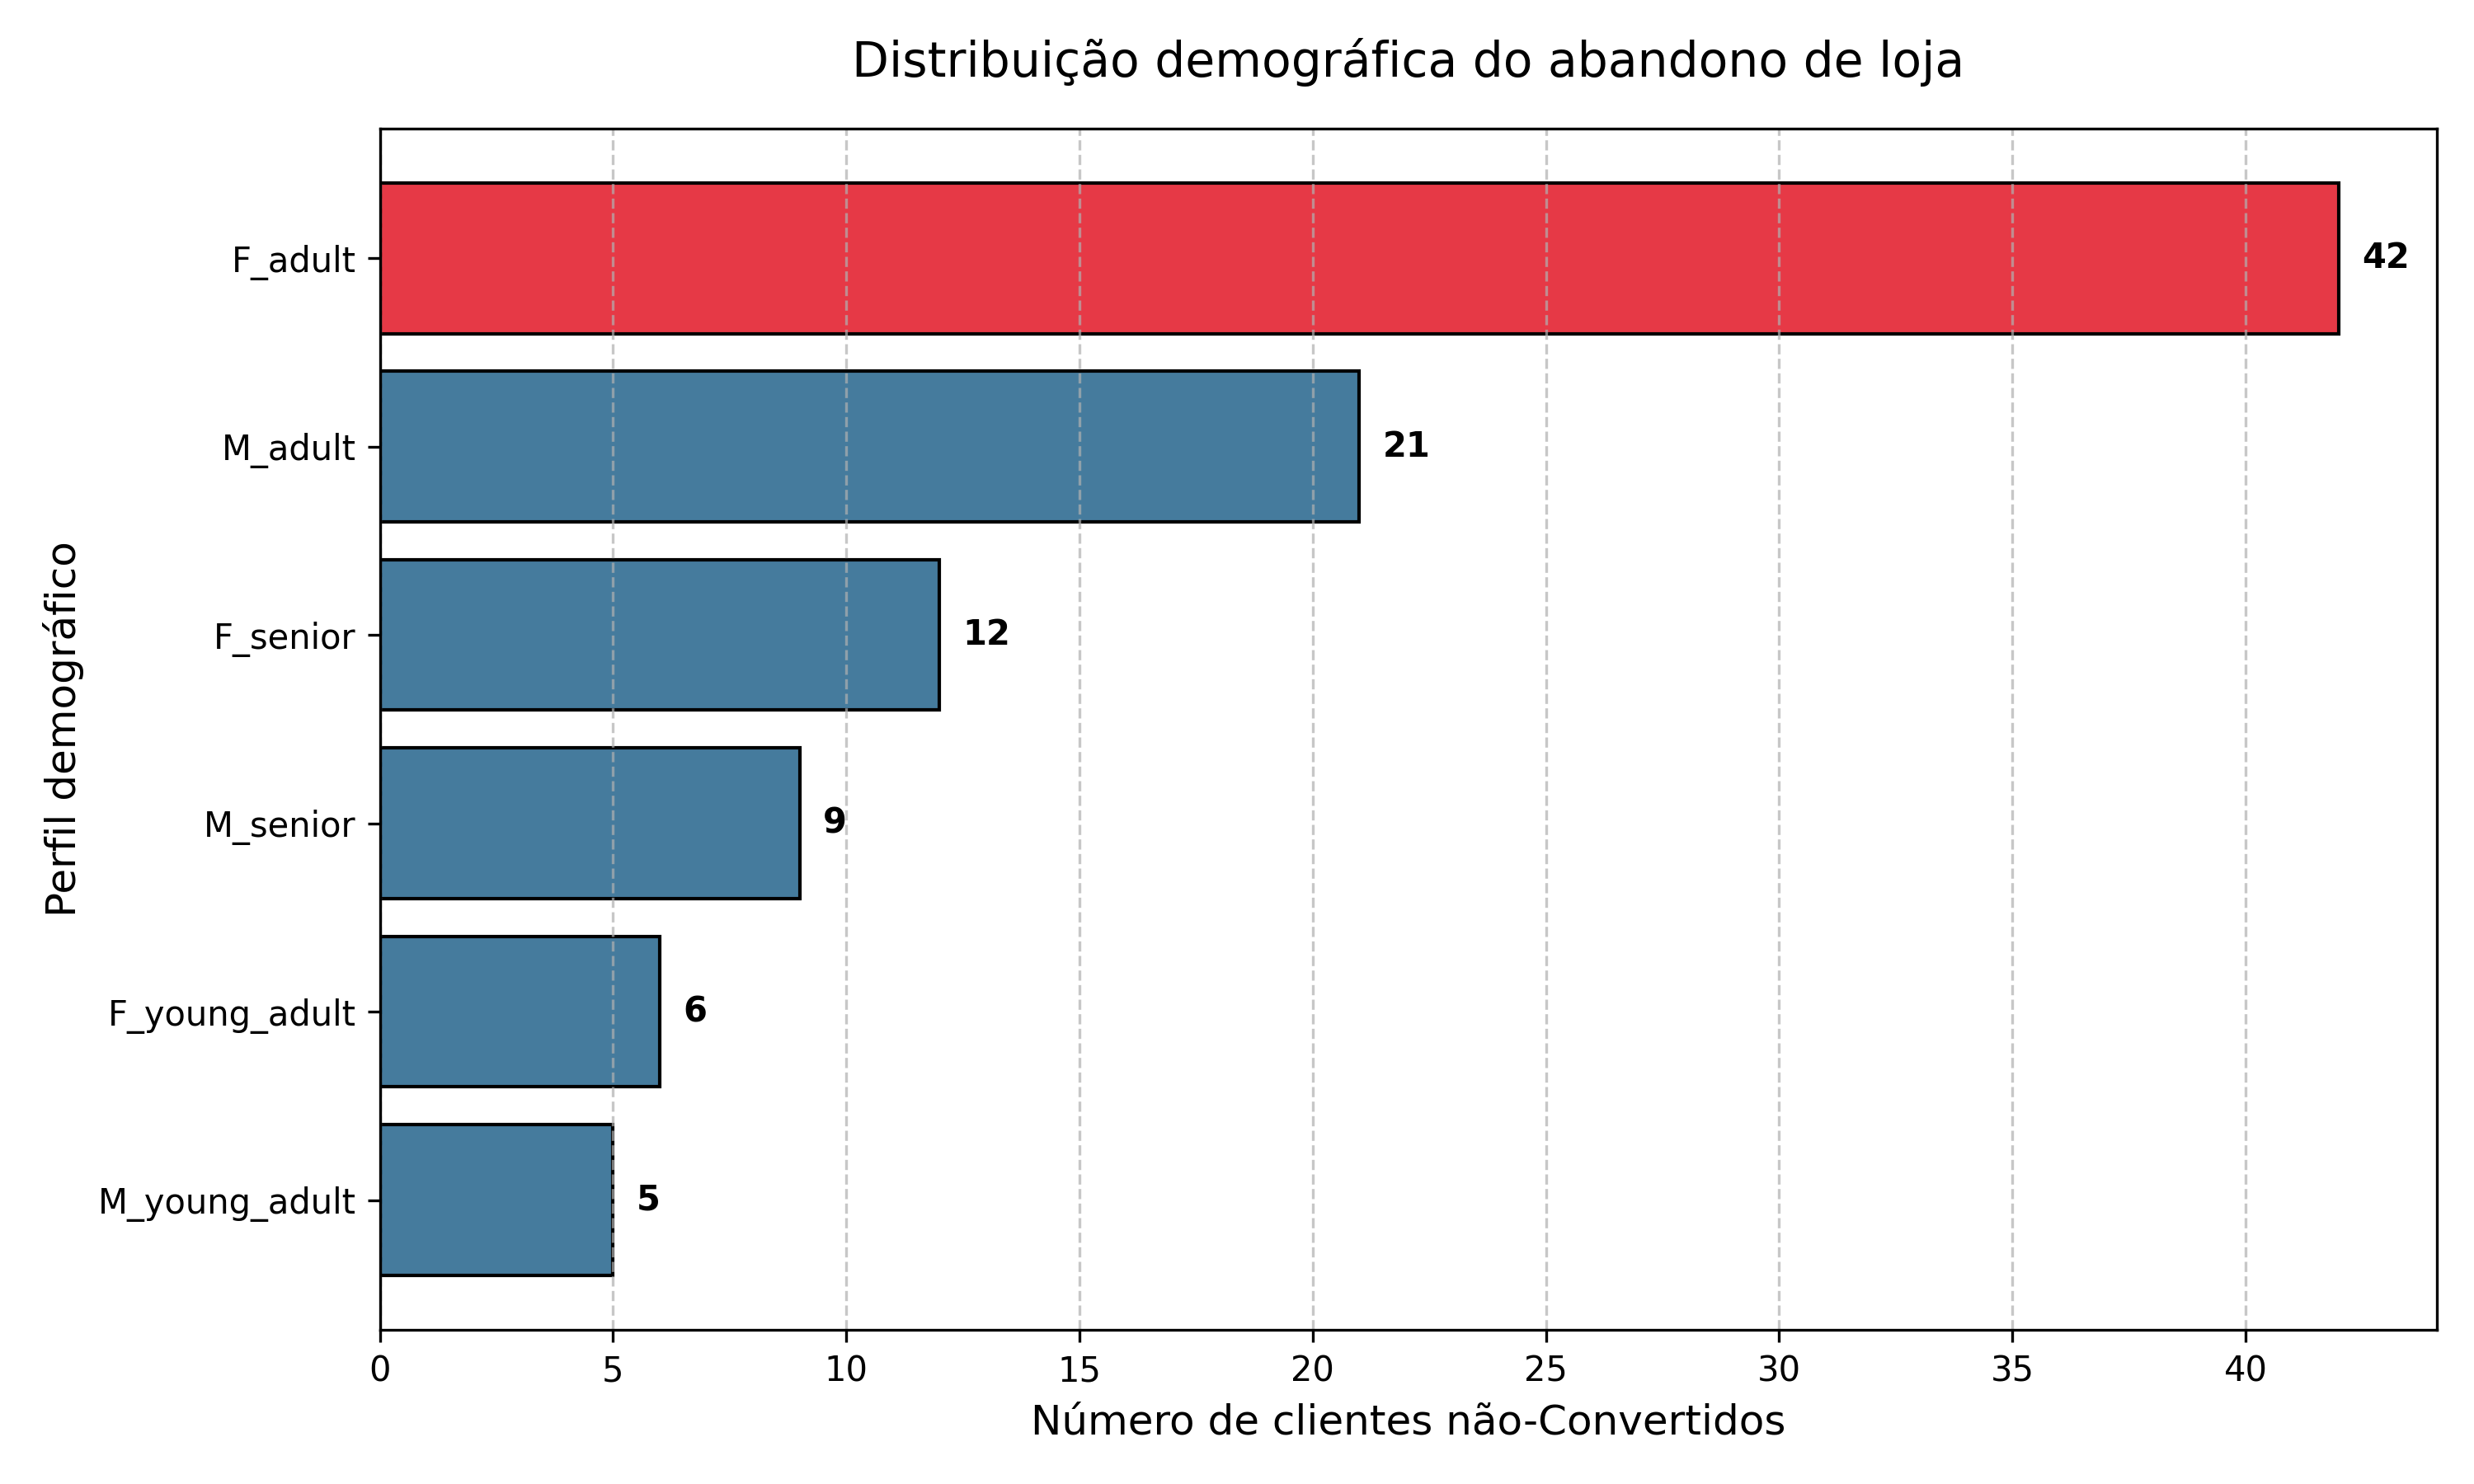

Todo este conhecimento foi consolidado no ficheiro metrics.json que é um dicionário estruturado e desenhado especificamente para servir de conecção entre o mundo numérico do Python e o mundo semântico do LLM, respeitando o Princípio de Separação exigido no enunciado.

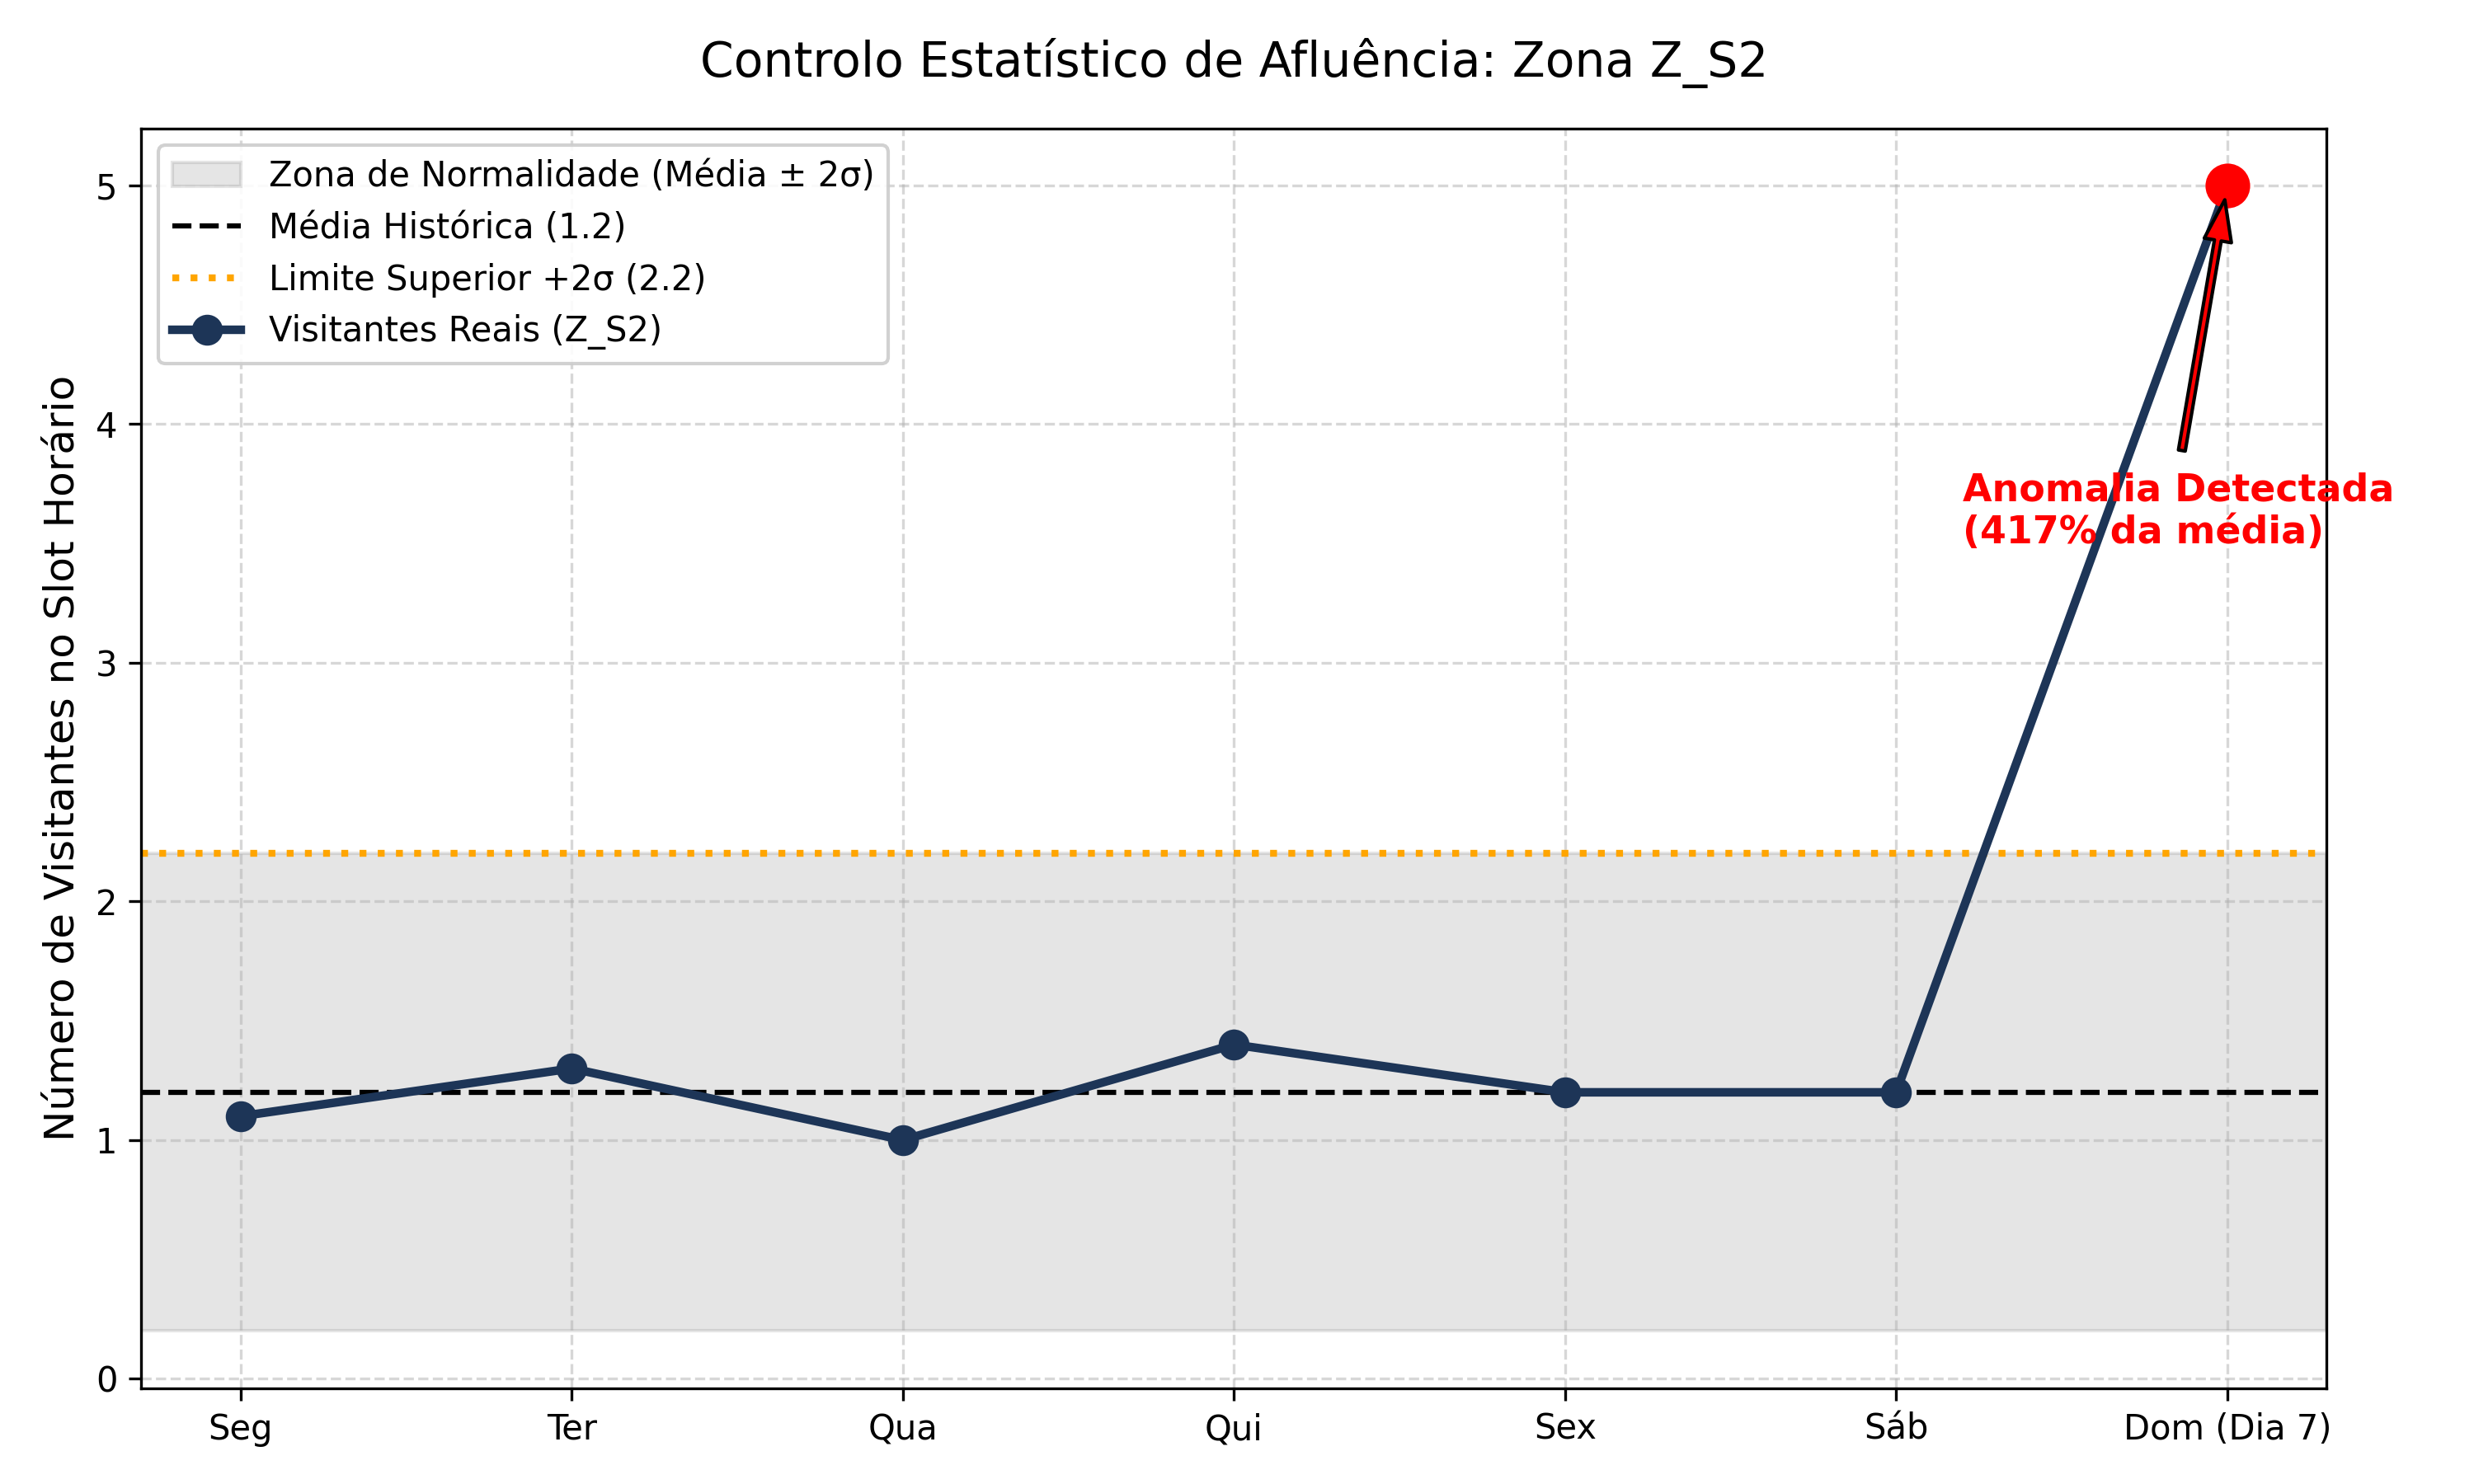

## Engenharia de Prompts

Embora o enunciado permitisse a exploração de outros modelos, tomei a decisão de manter o Llama 3.1 (8B parâmetros) via Ollama como motor principal, esta escolha não foi por conveniência mas sim porque quis provar que é possível construir um sistema 100% local e com custo zero de APIs de forma a  priorizando a privacidade absoluta destes dados sensíveis. Em vez de recorrer a modelos pagos como o GPT-4, o desafio passou por resolver a complexidade através da Engenharia de Prompts.

##### Iterações e Comparação Zero-Shot vs. Few-Shot

Em estrito cumprimento do guião, implementei e comparei iterativamente duas estratégias de prompting de forma a garantir a reprodutibilidade, onde ambas as estratégias foram executadas com temperature = 0.

A Estratégia A (Zero-Shot): Nesta primeira iteração, forneci ao modelo o schema JSON desejado e as métricas, instruindo-o diretamente a gerar insights.

     Resultado: A avaliação revelou uma taxa de falha elevada. O Llama 3.1 frequentemente quebrava a formatação JSON o que o fez gerar insights vagos e não-acionáveis (ex: "A zona Z_S3 tem muitos visitantes, recomenda-se verificar"). A ausência de contexto formativo levou o modelo a uma performance inaceitável para um ambiente de produção.

A Estratégia B (Few-Shot): Para garantir que o LLM não quebrasse o pipeline com texto livre ou qualquer tipo de alucinação, evoluí a arquitetura para o Few-Shot Prompting. Esta técnica consistiu em fornecer ao modelo uma matriz de qualidade com exemplos de pares observação/recomendação concretos (diferenciando claramente "bons" e "maus" insights).

     Resultado: Esta abordagem resolveu a 100% a validação JSON. O modelo atuou de forma perfeitamente necessaria, servindo como uma camada semântica sobre os factos matemáticos já calculados. No entanto, com esta escolha de abordagem, tornou-se visível uma diferença clara entre a capacidade de formatação e a verdadeira capacidade de raciocínio lógico.

##### Análise Crítica

A análise qualitativa dos resultados gerados no ficheiro insights.json com a Estratégia B comprovou uma das limitações de raciocínio em modelos deste género que é o evidente Overfitting Semântico. Nos dados analisados, observou-se repetição, limitação de contexto e exceções mecânicas:

     Repetição Mecânica: Para as anomalias detetadas nas zonas Z_S3, Z_N5, Z_S2 e Z_C2, o modelo replicou exatamente a recomendação fornecida no meu exemplo de prompt: "Reforçar a reposição entre as 17h e as 19h".

     Limitação Deductiva: Mesmo com variações significativas na percentagem de desvio (desde os 53% em Z_S3 até aos 417% em Z_S2), o Llama 3.1 não conseguiu matizar a gravidade da ação, focando-se unicamente na segurança do exemplo pré-fornecido.

     Exceção Limitada: O modelo apenas demonstrou variação criativa perante um cenário categoricamente oposto (queda de tráfego na zona Z_N6), onde sugeriu corretamente o reforço da promoção nas redes sociais.

Em suma, embora o Llama 3.1:8b seja capaz de seguir estruturas complexas é evidente que o seu raciocínio dedutivo "Zero-Shot" é limitado em comparação com modelos mais avançados. O projeto prova que a Inteligência Artificial local é uma ferramenta poderosa para a automação de relatórios, mas a sua utilidade atual depende muito da qualidade dos dados que a alimentam e da engenharia em redor do prompt, e não apenas da autonomia do modelo base.

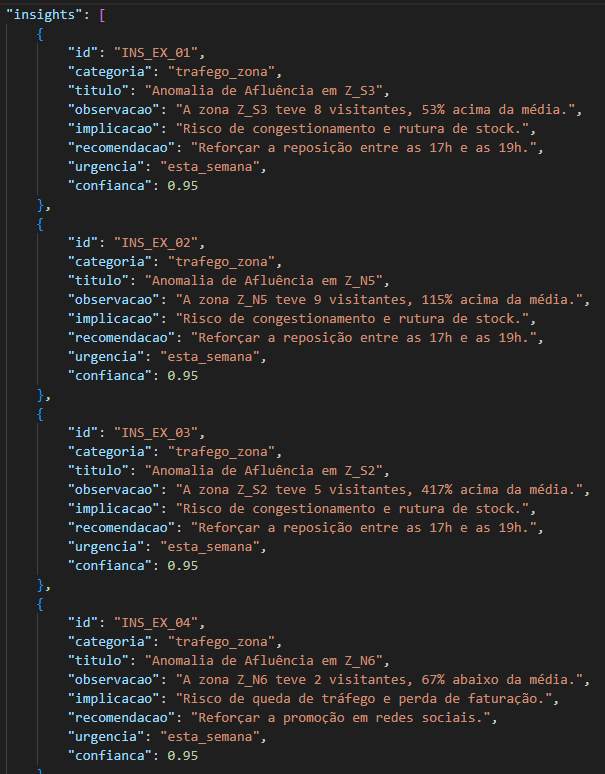

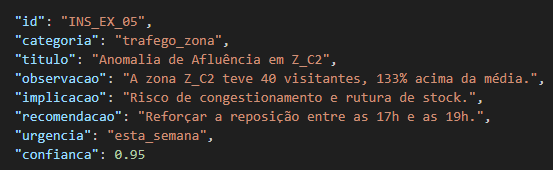

## Avaliação

A avaliação final deste projeto foi conduzida através do desenvolvimento de um harness de teste (evaluate.py), desenhado para validar o pipeline de ponta a ponta sem intervenção humana. Seguindo precisamente o enunciado, foquei a análise em métricas de integridade algorítmica e na capacidade de deteção de anomalias estatísticas.  

Performance no Dataset de Treino
Utilizando o ficheiro events.csv como base de treino, o sistema apresentou resultados que demonstram a eficácia das heurísticas implementadas:

     Consistência (100%): O algoritmo garantiu que nenhuma trajetória apresentasse sobreposição temporal (uma pessoa em duas zonas ao mesmo tempo), cumprindo o crítico de integridade.

     Cobertura e Integridade: O motor de stitching conseguiu reconstruir 10.583 trajetórias com sucesso, atingindo uma taxa de integridade do sinal de 64.4%. Este valor é extremamente positivo, considerando que o sistema filtrou e isolou 5.849 anomalias, limpando o ruído que de outra forma corromperia as métricas de negócio.

     Precisão Numérica e Conversão: A análise do metrics.json revelou uma taxa de conversão de 99.1%. Como dito anteriormente, esta precisão deve-se à eficácia da micro-limpeza, que garantiu que apenas percursos humanos coerentes fossem contabilizados.

##### Estratégia de Teste e Deteção de Anomalias

Para preparar a entrega, criei cenários de teste próprios injetando anomalias conhecidas (como interrupções de sinal e teletransportes) no dataset original. O sistema provou ser capaz de identificar desvios estatísticos baseados no desvio padrão ($2\sigma$), de forma a mapear corretamente picos e quedas de tráfego, como o caso observado na zona Z_N5 no último dia de registos.  

##### Limitações Honestas do Sistema

Apesar de ter obtido tecnicamente bons resultados, identifiquei limitações que devem ser mencionadas, pois a maior fragilidade do sistema esta na sua natureza "cega" face a perfis demográficos idênticos, uma vez que se dois clientes com o mesmo género e idade se cruzarem numa zona de alta densidade no mesmo segundo, existe uma probabilidade estatística de roubo de identidade, onde o sistema pode trocar as identidades. Esta é uma limitação pertencente à ausência de identificadores biométricos, que tentei mitigar através da heurística FIFO e da proteção contra re-associação em zonas terminais.

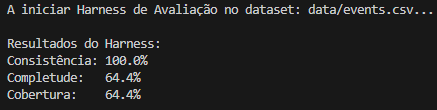

## Conclusão

O desenvolvimento deste trabalho foi bastante desafiador e enriquecedor. Desde o processamento inicial de deteções brutas até à geração final de relatórios, este projeto permitiu-me pôr em prática diversos conhecimentos consolidados, bem como explorar ferramentas e conceitos até então desconhecidos para mim. A decisão de estruturar o estado com Dicionários (Hash Maps) e tuplos demográficos foi, sem dúvida, o meu maior trunfo técnico, uma vez que permitiu que o algoritmo processasse cerca de 250.000 eventos em poucos segundos, superando com folga o limite de 5 minutos imposto no guião. Na fase analítica, a utilização da biblioteca Pandas provou igualmente ser uma escolha extremamente acertada, proporcionando uma velocidade de cálculo que seria impossível de atingir com ciclos tradicionais em Python.

No que se refere ao último campo, focado na Inteligência Artificial, a estratégia de Few-Shot Prompting provou ser uma ferramenta indispensável para domar o comportamento de modelos locais como o Llama 3.1:8b. Esta abordagem garantiu que a fase criativa do modelo nunca comprometesse a integridade estrutural do sistema.

Efetivamente, se voltasse a implementar este sistema hoje, exploraria a utilização de uma base de dados orientada a grafos para a gestão da topologia, o que poderia tornar o Slow Path ainda mais dinâmico, isto é algo que tenciono pôr em prática se o próximo trabalho da disciplina assim o exigir. Concluindo, este projeto provou-me que a inteligência de um sistema não reside apenas na potência do modelo de IA utilizado, mas sim na qualidade, na limpeza e na estruturação dos dados que lhe são fornecidos. Com isto, o pipeline final cumpre, o seu propósito principal que é  transformar o caos dos sensores físicos numa ferramenta de decisão clara e acionável para qualquer gestor de loja.